In [1]:
import numpy as np
import matplotlib.pyplot as plt

# pytorch stuff
import torch
import torch.nn as nn
from torch.nn import functional as F

from transformers import AutoModelForCausalLM, AutoTokenizer

# for text printing
import textwrap

!pip install torchinfo
from torchinfo import summary

import requests

In [2]:
# Eleuther's tokenizer
tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neo-125m")
tokenizer.pad_token_id = tokenizer.encode(' ')[0]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
# Load two GPT-Neo models
modelAlice = AutoModelForCausalLM.from_pretrained("EleutherAI/gpt-neo-125m")
modelEAP = AutoModelForCausalLM.from_pretrained("EleutherAI/gpt-neo-125m")

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelAlice.to(device)
modelEAP.to(device)
#

GPTNeoForCausalLM(
  (transformer): GPTNeoModel(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(2048, 768)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPTNeoBlock(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPTNeoAttention(
          (attention): GPTNeoSelfAttention(
            (attn_dropout): Dropout(p=0.0, inplace=False)
            (resid_dropout): Dropout(p=0.0, inplace=False)
            (k_proj): Linear(in_features=768, out_features=768, bias=False)
            (v_proj): Linear(in_features=768, out_features=768, bias=False)
            (q_proj): Linear(in_features=768, out_features=768, bias=False)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPTNeoMLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (c_proj): Linear(in_fe

In [5]:
# model summary
X = tokenizer.encode("What did the Red Queen say to Alice?", return_tensors="pt").to(device)
summary(modelAlice, input_data=X, col_names=["input_size", "output_size", "num_params"],row_settings=["var_names"])
#

Layer (type (var_name))                                      Input Shape               Output Shape              Param #
GPTNeoForCausalLM (GPTNeoForCausalLM)                        [1, 9]                    --                        --
├─GPTNeoModel (transformer)                                  [1, 9]                    --                        --
│    └─Embedding (wte)                                       [1, 9]                    [1, 9, 768]               38,597,376
│    └─Embedding (wpe)                                       [1, 9]                    [1, 9, 768]               1,572,864
│    └─Dropout (drop)                                        [1, 9, 768]               [1, 9, 768]               --
│    └─ModuleList (h)                                        --                        --                        --
│    │    └─GPTNeoBlock (0)                                  [1, 9, 768]               [1, 9, 768]               7,085,568
│    │    └─GPTNeoBlock (1)                  

In [6]:
# Import texts for "Through the Looking Glass"
text = requests.get('https://www.gutenberg.org/cache/epub/11/pg11.txt').text
aliceTokens =torch.tensor(tokenizer.encode(text),dtype=torch.long)
aliceTokens.shape

Token indices sequence length is longer than the specified maximum sequence length for this model (52954 > 2048). Running this sequence through the model will result in indexing errors


torch.Size([52954])

In [7]:
# Import texts for Edgar Allen Poe"
text = requests.get('https://www.gutenberg.org/cache/epub/2148/pg2148.txt').text
eapTokens =torch.tensor(tokenizer.encode(text),dtype=torch.long)
eapTokens.shape

torch.Size([197306])

In [8]:
print(f'Alice in Wonderland has {len(aliceTokens):7,} tokens')
print(f'Edgar Allen Poe text has {len(eapTokens):7,} tokens')

Alice in Wonderland has  52,954 tokens
Edgar Allen Poe text has 197,306 tokens


In [9]:
# Create a vector of all tokens for both books with words >= 3 charcaters
aliceTokens_filtered = np.full(len(aliceTokens), fill_value=-1, dtype=int)
eapTokens_filtered = np.full(len(eapTokens), fill_value=-1, dtype=int)

aliceTokens_filtered = np.where([len(tokenizer.decode(t)) > 2 for t in aliceTokens], aliceTokens.numpy(), -1)

eapTokens_filtered = np.where([len(tokenizer.decode(t)) > 2 for t in eapTokens], eapTokens.numpy(), -1)

print(f'Alice in Wonderland has {(aliceTokens_filtered==-1).sum():,}/{len(aliceTokens_filtered):,} tokens, i.e. {100*((aliceTokens_filtered==-1).sum()/len(aliceTokens_filtered)):.2f} % tokens with less than 3 characters')

print(f'Edgar Allen Poe has {(eapTokens_filtered==-1).sum():,}/{len(eapTokens_filtered):,} tokens, i.e. {100*((eapTokens_filtered==-1).sum()/len(eapTokens_filtered)):.2f} % tokens with less than 3 characters')



Alice in Wonderland has 24,017/52,954 tokens, i.e. 45.35 % tokens with less than 3 characters
Edgar Allen Poe has 96,190/197,306 tokens, i.e. 48.75 % tokens with less than 3 characters


In [10]:
aliceTokens_filtered_top100 = aliceTokens_filtered[np.where(aliceTokens_filtered!=-1)]
eapTokens_filtered_top100 = eapTokens_filtered[np.where(eapTokens_filtered!=-1)]

In [11]:
from enum import unique
# find top 100 most frequent tokens/ words
tok_alice, counts_alice = np.unique(aliceTokens_filtered_top100, return_counts=True)
alice_top100_indices = np.argsort(counts_alice)[::-1][:100] # Store indices, not tokens

tok_eap, counts_eap = np.unique(eapTokens_filtered_top100, return_counts=True)
eap_top100_indices = np.argsort(counts_eap)[::-1][:100] # Already correct

print("Top 100 tokens in Alice in Wonderland")
print("-"*30)

print('\n'.join(f'Token "{tokenizer.decode(tok_alice[idx]).strip()}" occurs {counts_alice[idx]} times' for idx in alice_top100_indices if len(tokenizer.decode(tok_alice[idx]).strip()) > 3))

print("\nTop 100 tokens in Edgar Allen Poe")
print("-"*30)
print('\n'.join(f'Token "{tokenizer.decode(tok_eap[idx]).strip()}" occurs {counts_eap[idx]} times' for idx in eap_top100_indices if len(tokenizer.decode(tok_eap[idx]).strip()) > 3))

Top 100 tokens in Alice in Wonderland
------------------------------
Token "said" occurs 445 times
Token "Alice" occurs 331 times
Token "that" occurs 256 times
Token "with" occurs 209 times
Token "this" occurs 145 times
Token "very" occurs 120 times
Token "they" occurs 120 times
Token "little" occurs 114 times
Token "down" occurs 93 times
Token "about" occurs 89 times
Token "what" occurs 84 times
Token "were" occurs 83 times
Token "them" occurs 81 times
Token "like" occurs 81 times
Token "know" occurs 80 times
Token "went" occurs 79 times
Token "again" occurs 75 times
Token "have" occurs 75 times
Token "thought" occurs 73 times
Token "Project" occurs 73 times
Token "Gutenberg" occurs 71 times
Token "could" occurs 71 times
Token "herself" occurs 71 times
Token "Alice" occurs 70 times
Token "Queen" occurs 70 times
Token "into" occurs 66 times
Token "when" occurs 65 times
Token "then" occurs 65 times
Token "would" occurs 64 times
Token "there" occurs 62 times
Token "King" occurs 59 times


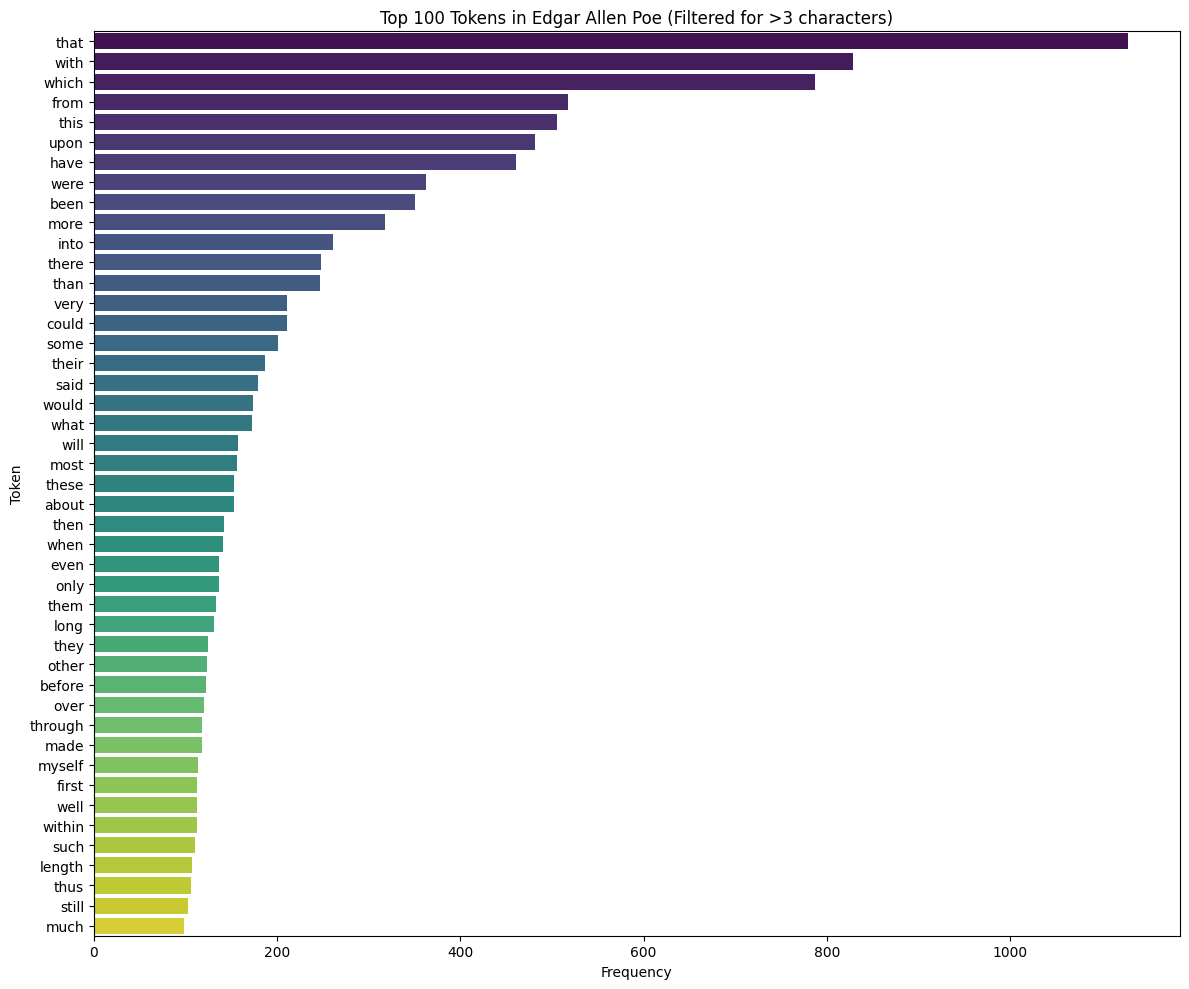

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract top 100 tokens and their counts for EAP
eap_top100_tokens = [tokenizer.decode(tok_eap[idx]) for idx in eap_top100_indices]
eap_top100_counts = [counts_eap[idx] for idx in eap_top100_indices]

# Filter out tokens with less than 3 characters (as done previously)
filtered_eap_tokens = []
filtered_eap_counts = []
for i, token_str in enumerate(eap_top100_tokens):
    if len(token_str.strip()) > 3:
        filtered_eap_tokens.append(token_str.strip())
        filtered_eap_counts.append(eap_top100_counts[i])

# Create a DataFrame for easy plotting
eap_df_top_tokens = pd.DataFrame({
    'Token': filtered_eap_tokens,
    'Count': filtered_eap_counts
})

# Sort by count in descending order
eap_df_top_tokens = eap_df_top_tokens.sort_values(by='Count', ascending=False)

# Plotting the top tokens
plt.figure(figsize=(12, 10))
sns.barplot(x='Count', y='Token', data=eap_df_top_tokens, hue='Token', palette='viridis', legend=False)
plt.title('Top 100 Tokens in Edgar Allen Poe (Filtered for >3 characters)')
plt.xlabel('Frequency')
plt.ylabel('Token')
plt.tight_layout()
plt.show()

In [13]:
import pandas as pd

# Extract top 100 tokens and their counts for Alice
alice_top100_tokens = [tokenizer.decode(tok_alice[idx]) for idx in alice_top100_indices]
alice_top100_counts = [counts_alice[idx] for idx in alice_top100_indices]

# Filter out tokens with less than 3 characters
filtered_alice_tokens = []
filtered_alice_counts = []
for i, token_str in enumerate(alice_top100_tokens):
    if len(token_str.strip()) > 3:
        filtered_alice_tokens.append(token_str.strip())
        filtered_alice_counts.append(alice_top100_counts[i])

# Create a DataFrame for Alice's top tokens
alice_df_top_tokens = pd.DataFrame({
    'Token': filtered_alice_tokens,
    'Count': filtered_alice_counts
})

# Sort by count in descending order
alice_df_top_tokens = alice_df_top_tokens.sort_values(by='Count', ascending=False)

print("Alice's Top Tokens DataFrame:")
print(alice_df_top_tokens.head())

Alice's Top Tokens DataFrame:
   Token  Count
0   said    445
1  Alice    331
2   that    256
3   with    209
4   this    145


In [14]:
common_tokens = pd.merge(alice_df_top_tokens, eap_df_top_tokens, on='Token', suffixes=('_Alice', '_EAP'))

# Prepare data for plotting
common_tokens_melted = common_tokens.melt(id_vars=['Token'], var_name='Author', value_name='Count')
common_tokens_melted['Author'] = common_tokens_melted['Author'].replace({'Count_Alice': 'Alice in Wonderland', 'Count_EAP': 'Edgar Allan Poe'})

print("Common Tokens DataFrame:")
print(common_tokens.head())

Common Tokens DataFrame:
  Token  Count_Alice  Count_EAP
0  said          445        179
1  that          256       1129
2  with          209        829
3  this          145        505
4  very          120        211


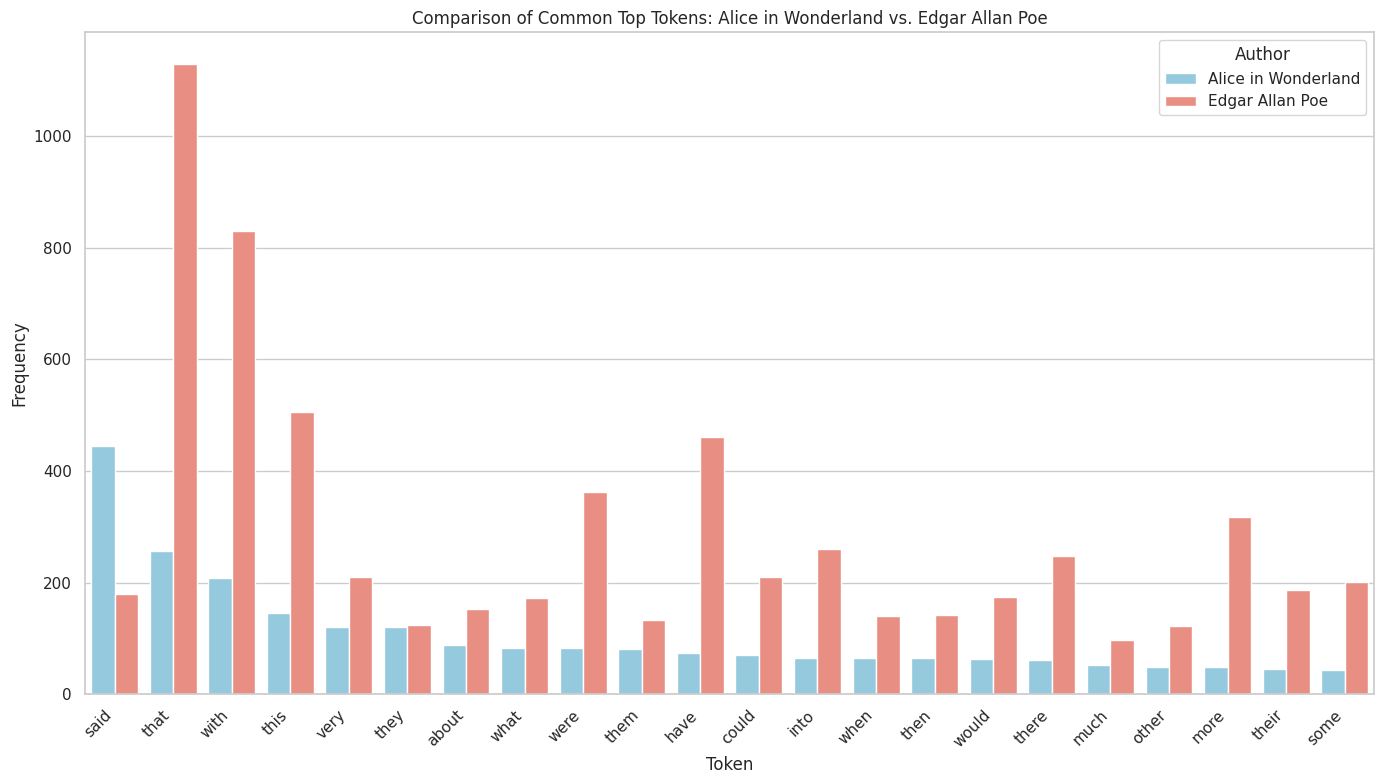

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for better aesthetics
sns.set_theme(style="whitegrid")

# Plotting the grouped bar chart
plt.figure(figsize=(14, 8))
sns.barplot(x='Token', y='Count', hue='Author', data=common_tokens_melted, palette={'Alice in Wonderland': 'skyblue', 'Edgar Allan Poe': 'salmon'})
plt.title('Comparison of Common Top Tokens: Alice in Wonderland vs. Edgar Allan Poe')
plt.xlabel('Token')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Author')
plt.tight_layout()
plt.show()

# Quantify the most common tokens

In [16]:
# Pre-training
numreps =  10 # number of random repetitions
numtoks = 100 # output length

# random starting tokens
randstarts = torch.randint(tokenizer.vocab_size,(numreps,1)).to(device)

# initialize the array for each model
tokenusage_alice = np.zeros((2,2)) # pre/ post-train
tokenusage_eap = np.zeros((2,2)) # pre/ post-train

# generate some data for Alice model
out_alice = modelAlice.generate(
  randstarts,
  max_length = numtoks+1,
  min_length = numtoks+1,
  do_sample  = True,
  bad_words_ids = [tokenizer.encode(tokenizer.eos_token)],
  pad_token_id = tokenizer.encode(tokenizer.eos_token)[0]
).cpu()

generated_alice = out_alice[:,1:].reshape(-1)

# generate some data for Edgar Allen Poe model
out_eap = modelEAP.generate(
  randstarts,
  max_length = numtoks+1,
  min_length = numtoks+1,
  do_sample  = True,
  bad_words_ids = [tokenizer.encode(tokenizer.eos_token)],
  pad_token_id = tokenizer.encode(tokenizer.eos_token)[0]
).cpu()

generated_eap = out_eap[:,1:].reshape(-1)

# calculate the percentage of generated tokens that are in top 100 tokens
tokenusage_alice[0,0] = np.mean(100 * np.isin(generated_alice.numpy(), aliceTokens_filtered_top100))
tokenusage_alice[0,1] = np.mean(100 * np.isin(generated_eap.numpy(), aliceTokens_filtered_top100))

tokenusage_eap[0,0] = np.mean(100 * np.isin(generated_eap.numpy(), eapTokens_filtered_top100))
tokenusage_eap[0,1] = np.mean(100 * np.isin(generated_alice.numpy(), eapTokens_filtered_top100))

print('Alice:')
print(tokenusage_alice)
print('EAP:')
print(tokenusage_eap)
#


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Alice:
[[46.5 40.6]
 [ 0.   0. ]]
EAP:
[[47.8 52.3]
 [ 0.   0. ]]


In [17]:
print('\n'.join(textwrap.wrap(tokenizer.decode(out_alice[0]),120)))

ebooks/assets/         'Content-Disposition-Disposition': 'inline',         'Content-Type-Version':
'{}'.format('application/vnd.microsoft.com/download', **file),         'Content-Transfer-Encoding': 'charmap',
'CreationId': 'f7a1dc09


In [18]:
print('\n'.join(textwrap.wrap(tokenizer.decode(out_eap[0]),120)))

ebook 2)    4: A Tribute to Charles Darwin   2nd (the book)    5: Charles Darwin, A Brief History of Biotechnology,
edited by Stephen White  In the United Kingdom:    1 (1 = Introduction or Theoretical or Political).   In Scotland:    1
(1 = The Great Book of the British Monographs).   (1 = The Scottish Papers).


# Fine tune the model

In [19]:
from transformers import get_linear_schedule_with_warmup

def trainLLM(num_steps, seq_len, batch_size, tokens, model, optimizer):
    model.train()
    train_loss = np.zeros(num_steps)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, int(0.1 * num_steps)),
        num_training_steps=num_steps
    )

    for step in range(num_steps):
        ix = torch.randint(len(tokens) - seq_len, size=(batch_size,))
        X  = tokens[ix[:, None] + torch.arange(seq_len)].to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(X, labels=X)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        train_loss[step] = loss.item()
        if step % 50 == 0:
            print(f"Step {step:4}/{num_steps}, loss: {loss.item():.4f}")

    return train_loss

In [20]:
# IMPORTANT: start from a fresh base model, not the collapsed one
modelAlice = AutoModelForCausalLM.from_pretrained("EleutherAI/gpt-neo-125m").to(device)

learning_rate = 1e-5
optimizer_alice = torch.optim.AdamW(
    modelAlice.parameters(),
    lr=learning_rate,
    weight_decay=0.01
)

alice_loss = trainLLM(
    num_steps=476,
    seq_len=256,
    batch_size=32,
    tokens=aliceTokens,
    model=modelAlice,
    optimizer=optimizer_alice
)


Step    0/476, loss: 2.5837
Step   50/476, loss: 2.2680
Step  100/476, loss: 2.1302
Step  150/476, loss: 1.9349
Step  200/476, loss: 1.9158
Step  250/476, loss: 1.8224
Step  300/476, loss: 1.8244
Step  350/476, loss: 1.6906
Step  400/476, loss: 1.6711
Step  450/476, loss: 1.6619


In [21]:
# IMPORTANT: start from a fresh base model, not the collapsed one
modelEAP = AutoModelForCausalLM.from_pretrained("EleutherAI/gpt-neo-125m").to(device)

learning_rate = 1e-5
optimizer_eap = torch.optim.AdamW(
    modelEAP.parameters(),
    lr=learning_rate,
    weight_decay=0.01
)

eap_loss = trainLLM(
    num_steps=476,
    seq_len=256,
    batch_size=32,
    tokens=eapTokens,
    model=modelEAP,
    optimizer=optimizer_eap
)


Step    0/476, loss: 2.7200
Step   50/476, loss: 2.5077
Step  100/476, loss: 2.4391
Step  150/476, loss: 2.3145
Step  200/476, loss: 2.2785
Step  250/476, loss: 2.2788
Step  300/476, loss: 2.2712
Step  350/476, loss: 2.2719
Step  400/476, loss: 2.2979
Step  450/476, loss: 2.2044


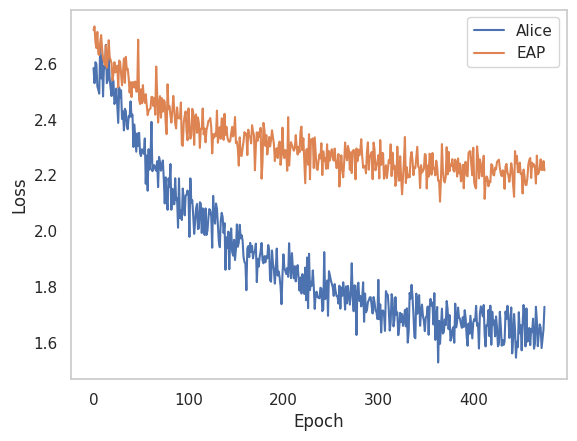

In [22]:
# Plot the losses
plt.plot(alice_loss, label='Alice')
plt.plot(eap_loss, label='EAP')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)
plt.show()

In [23]:
# Pre-training
numreps =  10 # number of random repetitions
numtoks = 100 # output length

# random starting tokens
randstarts = torch.randint(tokenizer.vocab_size,(numreps,1)).to(device)

# initialize the array for each model
tokenusage_alice = np.zeros((2,2)) # pre/ post-train
tokenusage_eap = np.zeros((2,2)) # pre/ post-train

# generate some data for Alice model
out_alice = modelAlice.generate(
  randstarts,
  max_length = numtoks+1,
  min_length = numtoks+1,
  do_sample  = True,
  bad_words_ids = [tokenizer.encode(tokenizer.eos_token)],
  pad_token_id = tokenizer.encode(tokenizer.eos_token)[0]
).cpu()

generated_alice = out_alice[:,1:].reshape(-1)

# generate some data for Edgar Allen Poe model
out_eap = modelEAP.generate(
  randstarts,
  max_length = numtoks+1,
  min_length = numtoks+1,
  do_sample  = True,
  bad_words_ids = [tokenizer.encode(tokenizer.eos_token)],
  pad_token_id = tokenizer.encode(tokenizer.eos_token)[0]
).cpu()

generated_eap = out_eap[:,1:].reshape(-1)

# calculate the percentage of generated tokens that are in top 100 tokens
tokenusage_alice[0,0] = np.mean(100 * np.isin(generated_alice.numpy(), aliceTokens_filtered_top100))
tokenusage_alice[0,1] = np.mean(100 * np.isin(generated_eap.numpy(), aliceTokens_filtered_top100))

tokenusage_eap[0,0] = np.mean(100 * np.isin(generated_eap.numpy(), eapTokens_filtered_top100))
tokenusage_eap[0,1] = np.mean(100 * np.isin(generated_alice.numpy(), eapTokens_filtered_top100))

print('Alice:')
print(tokenusage_alice)
print('EAP:')
print(tokenusage_eap)
#


Alice:
[[46.9 45. ]
 [ 0.   0. ]]
EAP:
[[50.3 43.6]
 [ 0.   0. ]]


In [24]:
# Qualitative assessment of the models
tokenizer.pad_token = tokenizer.eos_token
prompt = "What did the Red Queen say to Alice?"

enc = tokenizer(prompt, return_tensors="pt")
input_ids = enc["input_ids"].to(device)
attention_mask = enc["attention_mask"].to(device)

with torch.no_grad():
    out_alice = modelAlice.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=100,
        do_sample=True,
        temperature=0.8,
        top_p=0.9,
        repetition_penalty=1.15,
        no_repeat_ngram_size=3,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id,
    )


with torch.no_grad():
    out_eap = modelEAP.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=100,
        do_sample=True,
        temperature=0.8,
        top_p=0.9,
        repetition_penalty=1.15,
        no_repeat_ngram_size=3,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id,
    )

print('Alice:')
print('\n'.join(textwrap.wrap(tokenizer.decode(out_alice[0]),120)))
print('EAP:')
print('\n'.join(textwrap.wrap(tokenizer.decode(out_eap[0]),120)))
#

Alice:
What did the Red Queen say to Alice?    The Duchess turned pale, and said in a low voice, “I’m very glad you’re  in good
health, my dear. But now I must go and fetch the rest of the  ladies and children that have been waiting in the hall,
and bring them  back here.”  CHAPTER FOURTEEN.  Alice went into the garden, and looked about her for some time round
again,
EAP:
What did the Red Queen say to Alice?” I asked.“When you were     then in my company, you made no answer, but with a very
unusual      “How can I help it?’”    “You know me well enough to be sure that I am not alone. I am a  beautiful woman,
and have been for some years an easy mistress. You  have heard me speak of my beauty and of my own,
